# Hypothesis Testing

In [ ]:
## Warning: to compile the notes you need the "bookdown" and the "broom" packages. Install them by
## running install.packages, see the commented lines below

if (!require("tidyverse")) {
  install.packages("tidyverse")
}

if (!require("broom")) {
  install.packages("broom")
}

suppressMessages(library(tidyverse))
suppressMessages(library(broom))

# Draw R repeated samples directly from formula generators (n * R rows total).
# formulas[[1]]: response lm-style formula (e.g., y ~ 10 + 1.5 * x1 - 2 * x2)
# formulas[[2:]]: generators for covariates, including noise e (e.g., e ~ normal(0, 1))
sample_from_population_formula <- function(formulas, reg_formula, n, R, seed = NULL) {
  if (!is.list(formulas) || length(formulas) < 3) {
    stop("`formulas` must be a list with response first, then generators including `e`")
  }

  if (!all(map_lgl(formulas, ~ inherits(.x, "formula") && length(.x) == 3))) {
    stop("Every entry in `formulas` must be a two-sided formula")
  }

  if (!inherits(reg_formula, "formula") || length(reg_formula) != 3) {
    stop("`reg_formula` must be a two-sided regression formula")
  }

  if (!is.numeric(n) || length(n) != 1 || n <= 0 || n != as.integer(n)) {
    stop("`n` must be a positive integer")
  }

  if (!is.numeric(R) || length(R) != 1 || R <= 0 || R != as.integer(R)) {
    stop("`R` must be a positive integer")
  }

  if (!is.null(seed)) {
    set.seed(seed)
  }

  total_rows <- as.integer(n) * as.integer(R)

  # Evaluation environment with RNG helpers used inside formulas.
  eval_env <- new.env(parent = parent.frame())
  eval_env$N <- total_rows
  eval_env$bernoulli <- function(p) rbinom(eval_env$N, size = 1, prob = p)
  eval_env$normal <- function(mean = 0, sd = 1) rnorm(eval_env$N, mean = mean, sd = sd)
  eval_env$uniform <- function(min = 0, max = 1) runif(eval_env$N, min = min, max = max)

  response_formula <- formulas[[1]]
  generator_formulas <- formulas[-1]

  generator_names <- sapply(generator_formulas, function(f) {
    lhs_name <- all.vars(f[[2]])
    if (length(lhs_name) != 1) {
      stop("Each generator formula LHS must be a single variable name")
    }
    lhs_name
  }, simplify = TRUE, USE.NAMES = FALSE)

  if (!("e" %in% generator_names)) {
    stop("Include a noise formula in `formulas`, e.g. e ~ normal(0, 1)")
  }

  if (anyDuplicated(generator_names)) {
    stop("Generator formula LHS names must be unique")
  }

  generator_matrix <- sapply(generator_formulas, function(f) {
    values <- eval(f[[3]], envir = eval_env)
    if (length(values) != total_rows) {
      stop("Each generator formula RHS must evaluate to length n * R")
    }
    values
  })

  if (is.null(dim(generator_matrix))) {
    generator_matrix <- matrix(generator_matrix, ncol = 1)
  }
  colnames(generator_matrix) <- generator_names

  samples_dt <- tibble(sample_id = rep(seq_len(R), each = n)) |>
    bind_cols(as_tibble(as.data.frame(generator_matrix)))

  invisible(lapply(generator_names, function(name) {
    eval_env[[name]] <- samples_dt[[name]]
    NULL
  }))

  response_name <- all.vars(response_formula[[2]])
  if (length(response_name) != 1) {
    stop("Response formula LHS must be a single variable name")
  }

  response_rhs <- response_formula[[3]]
  response_vars <- all.vars(response_rhs)
  response_base <- eval(response_rhs, envir = eval_env)

  if (!is.numeric(response_base) || length(response_base) != total_rows) {
    stop("Response RHS must evaluate to a numeric vector of length n * R")
  }

  # If user omits + e from RHS, add the noise component automatically.
  response_values <- if ("e" %in% response_vars) response_base else response_base + eval_env$e

  samples_dt[[response_name]] <- response_values

  lm_results <- lm_by_sample(reg_formula, samples_dt)

  list(
    samples = samples_dt,
    lm_results = lm_results
  )
}

lm_by_sample <- function(formula, samples_dt) {
  samples_dt |>
    group_by(sample_id) |>
    group_modify(~ tidy(lm(formula, data = .x))) |>
    ungroup() |>
    select(sample_id, term, estimate, std.error)
}

# Example usage:
# population_description <- list(
#   y ~ 10 + 2 * group + e,
#   group ~ bernoulli(0.35),
#   e ~ normal(0, 2)
# )
# result <- sample_from_population_formula(
#   population_description,
#   reg_formula = y ~ group,
#   n = 50,
#   R = 1000,
#   seed = 42
# )
# samples_data <- result$samples_dt
# lm_results <- result$lm_results

In [104]:
population_description <- list(
  y ~ 10 + 2 * group + e,  
  group ~ bernoulli(0.35),
  e ~ normal(0, 2)
)

result <- sample_from_population_formula(
    population_description,
    reg_formula = y ~ group,
    n = 50, 
    R = 1000, 
    seed = 42
)

samples_data <- result$samples
lm_results <- result$lm_results

beta_1_estimates <- lm_results |> filter(term == "group") 

beta_1_estimates |> head()

sample_id,term,estimate,std.error
<int>,<chr>,<dbl>,<dbl>
1,group,1.329357,0.5907375
2,group,2.060339,0.6305141
3,group,2.092299,0.6434320
4,group,2.692886,0.5864537
5,group,2.436265,0.6296867
6,group,2.077633,0.7498940


In [87]:
lm(y ~ group, data = samples_data |> filter(sample_id == 1))


Call:
lm(formula = y ~ group, data = filter(samples_data, sample_id == 
    1))

Coefficients:
(Intercept)        group  
     10.117        1.329  


In [103]:
beta_1_estimates |>
    summarise(
      mean_estimate = mean(estimate),
      sd_estimate = sd(estimate),
      mean_se = mean(std.error)
    )

mean_estimate,sd_estimate,mean_se
<dbl>,<dbl>,<dbl>
1.994305,0.6013454,0.5970639


In [ ]:
# beta_1_estimates <- beta_1_estimates |>
#     mutate(
#         t_stat1 = ...
#     )

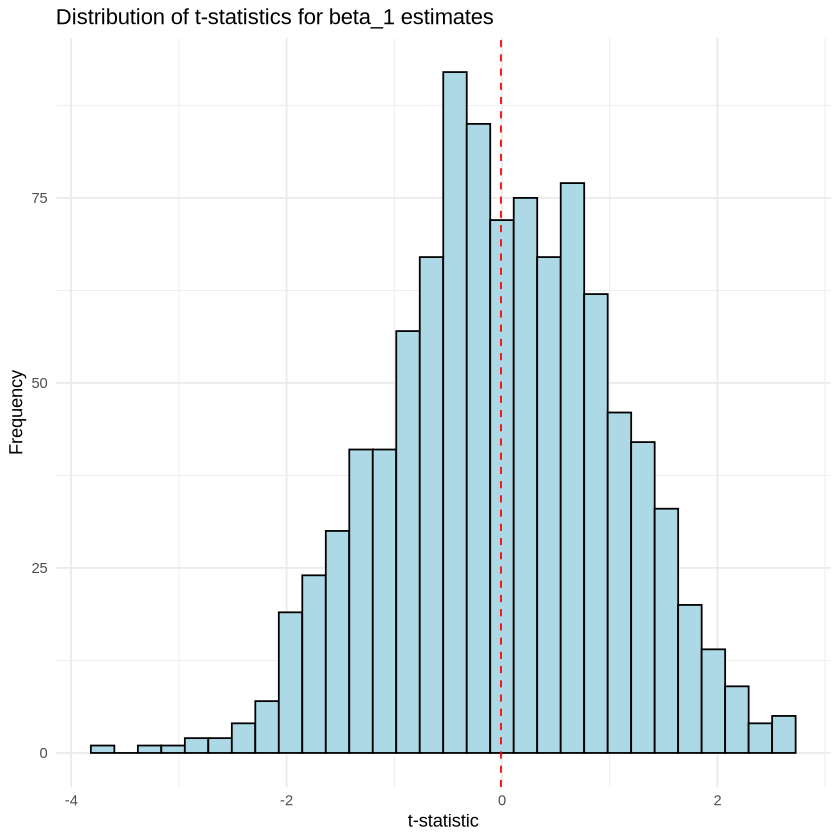

In [ ]:
# beta_1_estimates |> 
#     ggplot(aes(x = t_stat1)) +
#     geom_histogram(bins = 30, color = "black", fill = "lightblue") +
#     geom_vline(xintercept = mean(beta_1_estimates$t_stat1), color = "red", linetype = "dashed") +
#     labs(title = "Distribution of t-statistics for beta_1 estimates",
#          x = "t-statistic",
#          y = "Frequency") +
#     # xlim(-20, 20) +
#     theme_minimal()

[t-distribution](https://www.desmos.com/calculator/0vu2hvhymt)

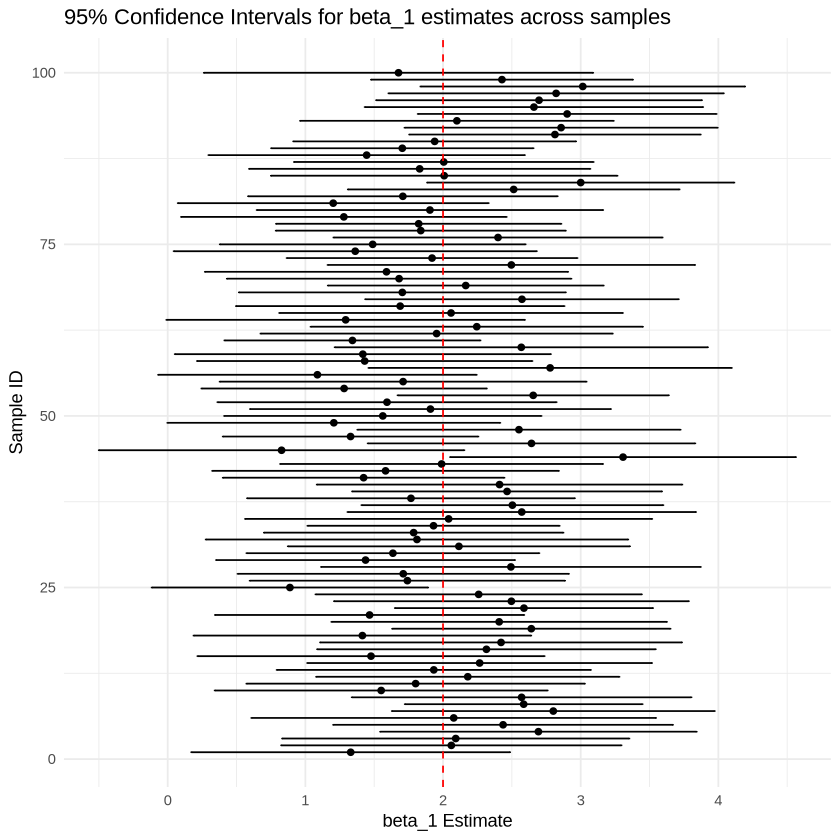

In [ ]:
# beta_1_estimates |>
#     filter(sample_id <= 100) |>
#     ggplot(aes(x = estimate, y=sample_id)) +
#     geom_point() +
#     geom_errorbarh(aes(xmin = CI_lower_95, xmax = CI_upper_95), height = 0.2) +
#     geom_vline(xintercept = 2, color = "red", linetype = "dashed") +
#     labs(title = "95% Confidence Intervals for beta_1 estimates across samples",
#          x = "beta_1 Estimate",
#          y = "Sample ID") +
#     theme_minimal()

In [109]:
s1_lm <- lm(y ~ group, data = samples_data |> filter(sample_id == 1))
s1_lm |> summary()


Call:
lm(formula = y ~ group, data = filter(samples_data, sample_id == 
    1))

Residuals:
    Min      1Q  Median      3Q     Max 
-5.1596 -1.0585 -0.1911  1.0226  5.0179 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  10.1171     0.4093   24.72   <2e-16 ***
group         1.3294     0.5907    2.25    0.029 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.087 on 48 degrees of freedom
Multiple R-squared:  0.09543,	Adjusted R-squared:  0.07659 
F-statistic: 5.064 on 1 and 48 DF,  p-value: 0.02905


[1] 3.098239

[1] 0.9379096

[1] 0.9379096

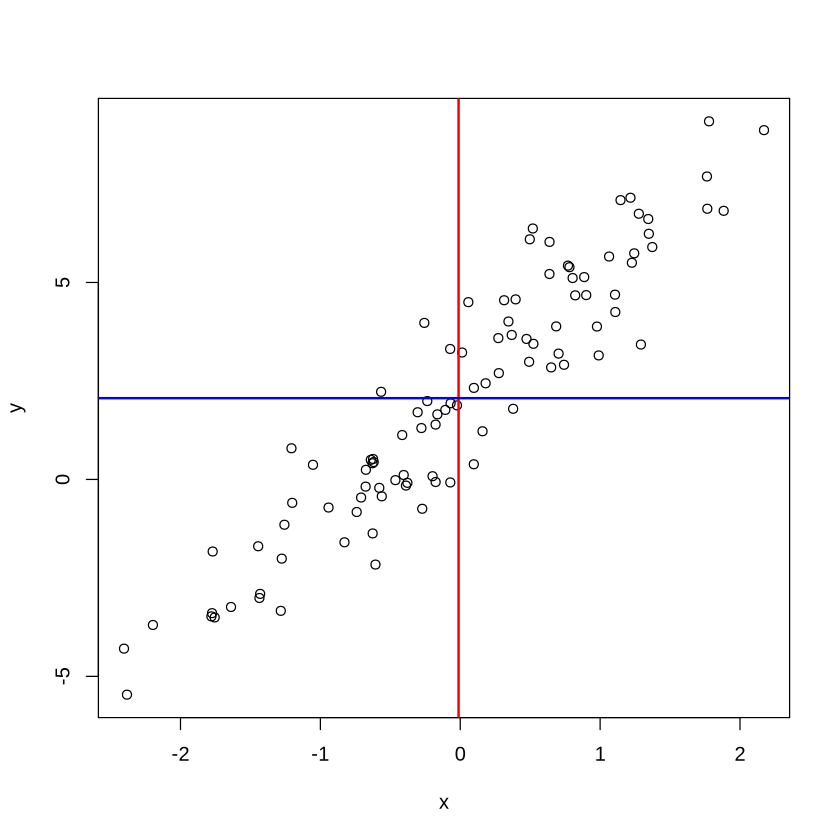

In [99]:
n <- 100

x <- rnorm(n)
y <- 2 + 3 * x + rnorm(n, sd = 1)

plot(x, y)
abline(v = mean(x), col = "red", lwd = 2)
abline(h = mean(y), col = "blue", lwd = 2)

x_std <- (x - mean(x)) / sd(x)
y_std <- (y - mean(y)) / sd(y)

cov(x, y)
cov(x_std, y_std)
cor(x, y)

In [102]:
confint(lm(y ~ x))

,2.5 %,97.5 %
(Intercept),1.873418,2.324716
x,2.795786,3.243538


In [101]:
lm(y_std ~ x_std)


Call:
lm(formula = y_std ~ x_std)

Coefficients:
(Intercept)        x_std  
 -1.167e-17    9.379e-01  
